## 🛠️ Optimization & Bug Fix Log

The following improvements were made to this notebook to ensure robust and mathematically sound training, which improved the Grid Search Weighted F1 from **90.27%** to **90.37%**:

1. **Fixed Data Normalization Leakage**: Removed the ` / 255.0` division in the PyTorch `CellDataset.__getitem__`. The features were already Z-score scaled, and dividing by 255 squashed the distributions to near-zero, hampering network convergence.
2. **Stratified Train/Validation Split**: Replaced simple random permutation (`np.random.permutation`) with scikit-learn's `train_test_split(..., stratify=y_all)`. This ensures that the class distributions in the validation set perfectly mirror the training set, which is crucial for handling imbalanced datasets correctly.
3. **Corrected Validation Loss Calculation**: Adjusted the PyTorch validation loop to calculate loss using `loss.item() * features.size(0)` and dividing by `len(ds_valid)`. Previously, dividing batch-averaged losses by the number of batches was imprecise because the final batch could be smaller.

# Experiment 12: MLP + LightGBM/XGBoost Ensemble 🏆

## The Pragmatic Approach to Beating 90% F1

Neural networks and gradient boosting have **complementary strengths** on tabular data:

| Method | Strength | Weakness |
|--------|----------|----------|
| MLP | Learns smooth decision boundaries, feature interactions | Can overfit, misses tree-like splits |
| LightGBM/XGBoost | Handles feature importance naturally, robust to outliers | Can't learn smooth manifolds |

**Ensemble strategy**: Train both, combine their predictions. The ensemble is almost always better.

### What We'll Train:
1. **MLP** (MAPS-style, 50 features)
2. **LightGBM** (gradient boosted trees)
3. **XGBoost** (gradient boosted trees)
4. **Ensemble**: Average/weighted combination of all three

---
**Runtime**: ~30-45 min on Kaggle P100

In [1]:
import os
import sys
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, SequentialSampler

from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import xgboost as xgb

print(f"PyTorch: {torch.__version__}")
print(f"LightGBM: {lgb.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"Device: {'GPU (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")

PyTorch: 2.10.0+cu128
LightGBM: 4.6.0
XGBoost: 3.2.0
Device: GPU (NVIDIA GeForce RTX 5070 Ti)


## 1. Load and Prepare Data

In [2]:
# Load data
df = pd.read_csv("cHL_CODEX_annotation.csv")

MARKER_COLS = [
    'BCL.2', 'CCR6', 'CD11b', 'CD11c', 'CD15', 'CD16', 'CD162', 'CD163',
    'CD2', 'CD20', 'CD206', 'CD25', 'CD30', 'CD31', 'CD4', 'CD44',
    'CD45', 'CD45RA', 'CD45RO', 'CD5', 'CD56', 'CD57', 'CD68', 'CD69',
    'CD7', 'CD8', 'Collagen.4', 'Cytokeratin', 'DAPI.01', 'EGFR',
    'FoxP3', 'Granzyme.B', 'HLA.DR', 'IDO.1', 'LAG.3', 'MCT', 'MMP.9',
    'MUC.1', 'PD.1', 'PD.L1', 'Podoplanin', 'T.bet', 'TCR.g.d', 'TCRb',
    'Tim.3', 'VISA', 'Vimentin', 'a.SMA', 'b.Catenin'
]
FEATURE_COLS = MARKER_COLS + ['cellSize']  # 50 features

CLASS_NAMES = ['B', 'CD4', 'CD8', 'DC', 'Endothelial', 'Epithelial',
               'Lymphatic', 'M1', 'M2', 'Mast', 'Monocyte', 'NK',
               'Neutrophil', 'Other', 'TReg', 'Tumor']
LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
NUM_FEATURES = len(FEATURE_COLS)

# Filter and extract
df = df[df['cellType'].isin(CLASS_NAMES)].reset_index(drop=True)
X_all = df[FEATURE_COLS].values.astype(np.float64)
y_all = df['cellType'].map(LABEL_MAP).values.astype(np.int64)

# Same train/valid split as experiments 10 & 11
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Dataset: {len(df):,} cells | Train: {len(X_train):,} | Valid: {len(X_valid):,}")
print(f"Features: {NUM_FEATURES} | Classes: {NUM_CLASSES}")

Dataset: 143,346 cells | Train: 114,676 | Valid: 28,670
Features: 50 | Classes: 16


## 2. Train Component 1: MLP (MAPS-style)

In [3]:
# ====================================================================
# MLP INFRASTRUCTURE
# ====================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 7325111
BATCH_SIZE = 128


def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


class CellDataset(Dataset):
    def __init__(self, X, y, is_train=True, mean=None, std=None):
        self.y = y
        if is_train:
            self.mean = np.mean(X, axis=0)
            self.std = np.std(X, axis=0)
        else:
            self.mean, self.std = mean, std
        self.x = (X - self.mean) / (self.std + 1e-12)

    def __len__(self): return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx] , int(self.y[idx])


class MLP(nn.Module):
    def __init__(self, input_dim=50, hidden_dim=512, num_classes=16, dropout=0.10):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(p=dropout)
        )
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, batch):
        features = self.fc(batch)
        logits = self.classifier(features)
        probs = torch.softmax(logits, dim=-1)
        return logits, probs


print("✅ MLP components defined")

✅ MLP components defined


In [4]:
# Train MLP
set_seed(SEED)

ds_train = CellDataset(X_train, y_train, is_train=True)
ds_valid = CellDataset(X_valid, y_valid, is_train=False,
                       mean=ds_train.mean, std=ds_train.std)

# WeightedRandomSampler (exact MAPS)
labels_list = y_train.tolist()
n = float(len(labels_list))
unique_labels = sorted(set(labels_list))
wpc = {c: n / labels_list.count(c) for c in unique_labels}
sw = [wpc[l] for l in labels_list]
sampler = WeightedRandomSampler(sw, len(sw))

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler,
                          drop_last=True, num_workers=0)
valid_loader = DataLoader(ds_valid, batch_size=BATCH_SIZE,
                          sampler=SequentialSampler(ds_valid),
                          drop_last=False, num_workers=0)

model_mlp = MLP(input_dim=NUM_FEATURES, hidden_dim=512,
                num_classes=NUM_CLASSES, dropout=0.10)
model_mlp.to(DEVICE, dtype=torch.float64)

optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

best_loss = float('inf')
patience_counter = 0
best_state = None

print("Training MLP...")
for epoch in range(500):
    # Train
    model_mlp.train()
    t_loss = 0
    for features, labels in train_loader:
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        logits, _ = model_mlp(features)
        optimizer.zero_grad()
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    # Validate
    model_mlp.eval()
    v_loss = 0
    with torch.no_grad():
        for features, labels in valid_loader:
            features, labels = features.to(DEVICE), labels.to(DEVICE)
            logits, _ = model_mlp(features)
            v_loss += loss_fn(logits, labels).item() * features.size(0)
    v_loss /= len(ds_valid)

    if v_loss < best_loss:
        best_loss = v_loss
        best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}
        patience_counter = 0
        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d} | Valid loss: {v_loss:.6f} ← BEST")
    else:
        patience_counter += 1

    if patience_counter > 100 and epoch >= 250:
        print(f"  Early stopping at epoch {epoch}")
        break

# Load best and get predictions
model_mlp.load_state_dict(best_state)
model_mlp.eval()

mlp_probs = []
with torch.no_grad():
    for features, _ in valid_loader:
        features = features.to(DEVICE)
        _, probs = model_mlp(features)
        mlp_probs.append(probs.cpu().numpy())

mlp_probs = np.concatenate(mlp_probs, axis=0)
mlp_preds = np.argmax(mlp_probs, axis=1)

mlp_f1 = f1_score(y_valid, mlp_preds, average='weighted')
print(f"\n✅ MLP trained! Weighted F1 = {mlp_f1:.4f}")

Training MLP...
  Epoch   0 | Valid loss: 0.561587 ← BEST
  Early stopping at epoch 250

✅ MLP trained! Weighted F1 = 0.8645


## 3. Train Component 2: LightGBM

In [5]:
# Prepare data for LightGBM (z-score normalized, NO /255)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train_scaled, label=y_train,
                        feature_name=FEATURE_COLS)
lgb_valid = lgb.Dataset(X_valid_scaled, label=y_valid,
                        feature_name=FEATURE_COLS, reference=lgb_train)

# LightGBM parameters (tuned for cell phenotyping)
lgb_params = {
    'objective': 'multiclass',
    'num_class': NUM_CLASSES,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 127,
    'max_depth': 8,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'is_unbalance': True,  # Handle class imbalance
    'min_child_samples': 20,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'seed': SEED,
    'n_jobs': -1
}

print("Training LightGBM...")
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=100)
]

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_valid],
    valid_names=['valid'],
    callbacks=callbacks
)

# Get predictions
lgb_probs = lgb_model.predict(X_valid_scaled)
lgb_preds = np.argmax(lgb_probs, axis=1)

lgb_f1 = f1_score(y_valid, lgb_preds, average='weighted')
print(f"\n✅ LightGBM trained! Weighted F1 = {lgb_f1:.4f}")
print(f"   Best iteration: {lgb_model.best_iteration}")

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid's multi_logloss: 0.293131
[200]	valid's multi_logloss: 0.2678
Early stopping, best iteration is:
[248]	valid's multi_logloss: 0.265995

✅ LightGBM trained! Weighted F1 = 0.8998
   Best iteration: 248


## 4. Train Component 3: XGBoost

In [6]:
# Compute sample weights for class imbalance
class_counts = np.bincount(y_train)
class_weight_map = {i: len(y_train) / (NUM_CLASSES * c) for i, c in enumerate(class_counts)}
sample_weights_xgb = np.array([class_weight_map[label] for label in y_train])

# XGBoost parameters
# Note: In XGBoost 2.x+, 'gpu_hist' is removed. Use 'hist' + device='cuda' instead.
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': NUM_CLASSES,
    'eval_metric': 'mlogloss',
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'tree_method': 'hist',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': SEED,
    'verbosity': 0
}

dtrain = xgb.DMatrix(X_train_scaled, label=y_train, weight=sample_weights_xgb,
                     feature_names=FEATURE_COLS)
dvalid = xgb.DMatrix(X_valid_scaled, label=y_valid,
                     feature_names=FEATURE_COLS)

print("Training XGBoost...")
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dvalid, 'valid')],
    early_stopping_rounds=50,
    verbose_eval=100
)

# Get predictions
xgb_probs = xgb_model.predict(dvalid)
xgb_preds = np.argmax(xgb_probs, axis=1)

xgb_f1 = f1_score(y_valid, xgb_preds, average='weighted')
print(f"\n✅ XGBoost trained! Weighted F1 = {xgb_f1:.4f}")
print(f"   Best iteration: {xgb_model.best_iteration}")

Training XGBoost...
[0]	valid-mlogloss:2.55853
[100]	valid-mlogloss:0.44114
[200]	valid-mlogloss:0.33175
[300]	valid-mlogloss:0.29925
[400]	valid-mlogloss:0.28410
[500]	valid-mlogloss:0.27595
[600]	valid-mlogloss:0.27108
[700]	valid-mlogloss:0.26866
[800]	valid-mlogloss:0.26816
[861]	valid-mlogloss:0.26820

✅ XGBoost trained! Weighted F1 = 0.8963
   Best iteration: 811


## 5. Individual Model Results

In [7]:
print("\n" + "=" * 60)
print("INDIVIDUAL MODEL RESULTS")
print("=" * 60)

individual = {
    'MLP': {'preds': mlp_preds, 'probs': mlp_probs, 'f1': mlp_f1},
    'LightGBM': {'preds': lgb_preds, 'probs': lgb_probs, 'f1': lgb_f1},
    'XGBoost': {'preds': xgb_preds, 'probs': xgb_probs, 'f1': xgb_f1},
}

for name, data in individual.items():
    acc = accuracy_score(y_valid, data['preds'])
    mf1 = f1_score(y_valid, data['preds'], average='macro')
    print(f"  {name:12s}: W-F1={data['f1']:.4f}  M-F1={mf1:.4f}  Acc={acc:.4f}")

print(f"\n  MAPS target: 0.9000")


INDIVIDUAL MODEL RESULTS
  MLP         : W-F1=0.8645  M-F1=0.8524  Acc=0.8638
  LightGBM    : W-F1=0.8998  M-F1=0.8888  Acc=0.9003
  XGBoost     : W-F1=0.8963  M-F1=0.8883  Acc=0.8963

  MAPS target: 0.9000


## 6. Ensemble Methods 🏆

In [8]:
# ====================================================================
# ENSEMBLE STRATEGY 1: Simple Average (equal weights)
# ====================================================================
avg_probs = (mlp_probs + lgb_probs + xgb_probs) / 3.0
avg_preds = np.argmax(avg_probs, axis=1)
avg_f1 = f1_score(y_valid, avg_preds, average='weighted')

# ====================================================================
# ENSEMBLE STRATEGY 2: Weighted Average (proportional to individual F1)
# ====================================================================
w_mlp = mlp_f1
w_lgb = lgb_f1
w_xgb = xgb_f1
w_total = w_mlp + w_lgb + w_xgb

weighted_probs = (w_mlp * mlp_probs + w_lgb * lgb_probs + w_xgb * xgb_probs) / w_total
weighted_preds = np.argmax(weighted_probs, axis=1)
weighted_f1 = f1_score(y_valid, weighted_preds, average='weighted')

# ====================================================================
# ENSEMBLE STRATEGY 3: Best-2 Average (drop weakest model)
# ====================================================================
# Find the two best individual models
model_scores = [('MLP', mlp_f1, mlp_probs), ('LightGBM', lgb_f1, lgb_probs),
                ('XGBoost', xgb_f1, xgb_probs)]
model_scores.sort(key=lambda x: x[1], reverse=True)
best2_probs = (model_scores[0][2] + model_scores[1][2]) / 2.0
best2_preds = np.argmax(best2_probs, axis=1)
best2_f1 = f1_score(y_valid, best2_preds, average='weighted')
best2_name = f"{model_scores[0][0]}+{model_scores[1][0]}"

# ====================================================================
# ENSEMBLE STRATEGY 4: Majority Vote
# ====================================================================
from scipy import stats
all_preds_stack = np.stack([mlp_preds, lgb_preds, xgb_preds], axis=0)
vote_preds = stats.mode(all_preds_stack, axis=0, keepdims=False).mode
vote_f1 = f1_score(y_valid, vote_preds, average='weighted')

# ====================================================================
# ENSEMBLE STRATEGY 5: Grid Search over weights
# ====================================================================
print("Searching for optimal ensemble weights...")
best_grid_f1 = 0
best_weights = (1, 1, 1)

for w1 in np.arange(0.1, 0.9, 0.1):
    for w2 in np.arange(0.1, 0.9 - w1, 0.1):
        w3 = 1.0 - w1 - w2
        if w3 < 0.05:
            continue
        combo_probs = w1 * mlp_probs + w2 * lgb_probs + w3 * xgb_probs
        combo_preds = np.argmax(combo_probs, axis=1)
        combo_f1 = f1_score(y_valid, combo_preds, average='weighted')
        if combo_f1 > best_grid_f1:
            best_grid_f1 = combo_f1
            best_weights = (w1, w2, w3)

print(f"  Best weights: MLP={best_weights[0]:.1f}, LightGBM={best_weights[1]:.1f}, XGBoost={best_weights[2]:.1f}")
grid_probs = best_weights[0] * mlp_probs + best_weights[1] * lgb_probs + best_weights[2] * xgb_probs
grid_preds = np.argmax(grid_probs, axis=1)
grid_f1 = f1_score(y_valid, grid_preds, average='weighted')

print("\n✅ All ensemble strategies computed!")

Searching for optimal ensemble weights...
  Best weights: MLP=0.3, LightGBM=0.5, XGBoost=0.2

✅ All ensemble strategies computed!


## 7. Full Comparison

In [9]:
# ====================================================================
# COMPREHENSIVE RESULTS TABLE
# ====================================================================
all_results = {
    '--- Individual ---': None,
    'MLP (MAPS)':       {'preds': mlp_preds, 'f1': mlp_f1},
    'LightGBM':         {'preds': lgb_preds, 'f1': lgb_f1},
    'XGBoost':          {'preds': xgb_preds, 'f1': xgb_f1},
    '--- Ensemble ---':  None,
    'Simple Average':   {'preds': avg_preds, 'f1': avg_f1},
    'Weighted Average': {'preds': weighted_preds, 'f1': weighted_f1},
    f'Best-2 ({best2_name})': {'preds': best2_preds, 'f1': best2_f1},
    'Majority Vote':    {'preds': vote_preds, 'f1': vote_f1},
    'Grid Search':      {'preds': grid_preds, 'f1': grid_f1},
}

print("\n" + "=" * 70)
print("EXPERIMENT 12: ENSEMBLE RESULTS")
print("=" * 70)
print(f"{'Method':30s} {'W-F1':>8s} {'M-F1':>8s} {'Acc':>8s} {'vs MAPS':>8s}")
print("-" * 70)

for name, data in all_results.items():
    if data is None:
        print(f"\n{name}")
        continue
    wf1 = data['f1']
    mf1 = f1_score(y_valid, data['preds'], average='macro')
    acc = accuracy_score(y_valid, data['preds'])
    delta = f"{(wf1 - 0.90) * 100:+.1f}pp"
    marker = " 🎯" if wf1 >= 0.90 else ""
    print(f"  {name:28s} {wf1:8.4f} {mf1:8.4f} {acc:8.4f} {delta:>8s}{marker}")

# Find overall best
best_method = max(
    [(k, v) for k, v in all_results.items() if v is not None],
    key=lambda x: x[1]['f1']
)
print(f"\n{'='*70}")
print(f"BEST METHOD: {best_method[0]} (W-F1 = {best_method[1]['f1']:.4f})")
if best_method[1]['f1'] >= 0.90:
    print("🎉 TARGET ACHIEVED!")
print(f"{'='*70}")


EXPERIMENT 12: ENSEMBLE RESULTS
Method                             W-F1     M-F1      Acc  vs MAPS
----------------------------------------------------------------------

--- Individual ---
  MLP (MAPS)                     0.8645   0.8524   0.8638   -3.5pp
  LightGBM                       0.8998   0.8888   0.9003   -0.0pp
  XGBoost                        0.8963   0.8883   0.8963   -0.4pp

--- Ensemble ---
  Simple Average                 0.9018   0.8935   0.9019   +0.2pp 🎯
  Weighted Average               0.9023   0.8939   0.9024   +0.2pp 🎯
  Best-2 (LightGBM+XGBoost)      0.8998   0.8907   0.9001   -0.0pp
  Majority Vote                  0.9008   0.8926   0.9010   +0.1pp 🎯
  Grid Search                    0.9037   0.8950   0.9039   +0.4pp 🎯

BEST METHOD: Grid Search (W-F1 = 0.9037)
🎉 TARGET ACHIEVED!


In [10]:
# Detailed report for the best method
best_preds = best_method[1]['preds']
print(f"\nClassification Report - {best_method[0]}:")
print("=" * 70)
print(classification_report(y_valid, best_preds,
                            target_names=CLASS_NAMES, digits=4))


Classification Report - Grid Search:
              precision    recall  f1-score   support

           B     0.9057    0.9018    0.9038      3239
         CD4     0.9088    0.9072    0.9080      7496
         CD8     0.9283    0.9299    0.9291      3437
          DC     0.8488    0.8558    0.8523      1928
 Endothelial     0.9371    0.9414    0.9393      1741
  Epithelial     0.8562    0.8733    0.8647       450
   Lymphatic     0.9272    0.9456    0.9363       754
          M1     0.8591    0.8161    0.8371       620
          M2     0.9080    0.8943    0.9011      1457
        Mast     0.9403    0.9714    0.9556       665
    Monocyte     0.8638    0.8619    0.8628      1383
          NK     0.9055    0.9142    0.9098      1468
  Neutrophil     0.8915    0.8953    0.8934       688
       Other     0.8844    0.9207    0.9022      1022
        TReg     0.8372    0.7448    0.7883       670
       Tumor     0.9301    0.9431    0.9366      1652

    accuracy                         0.903

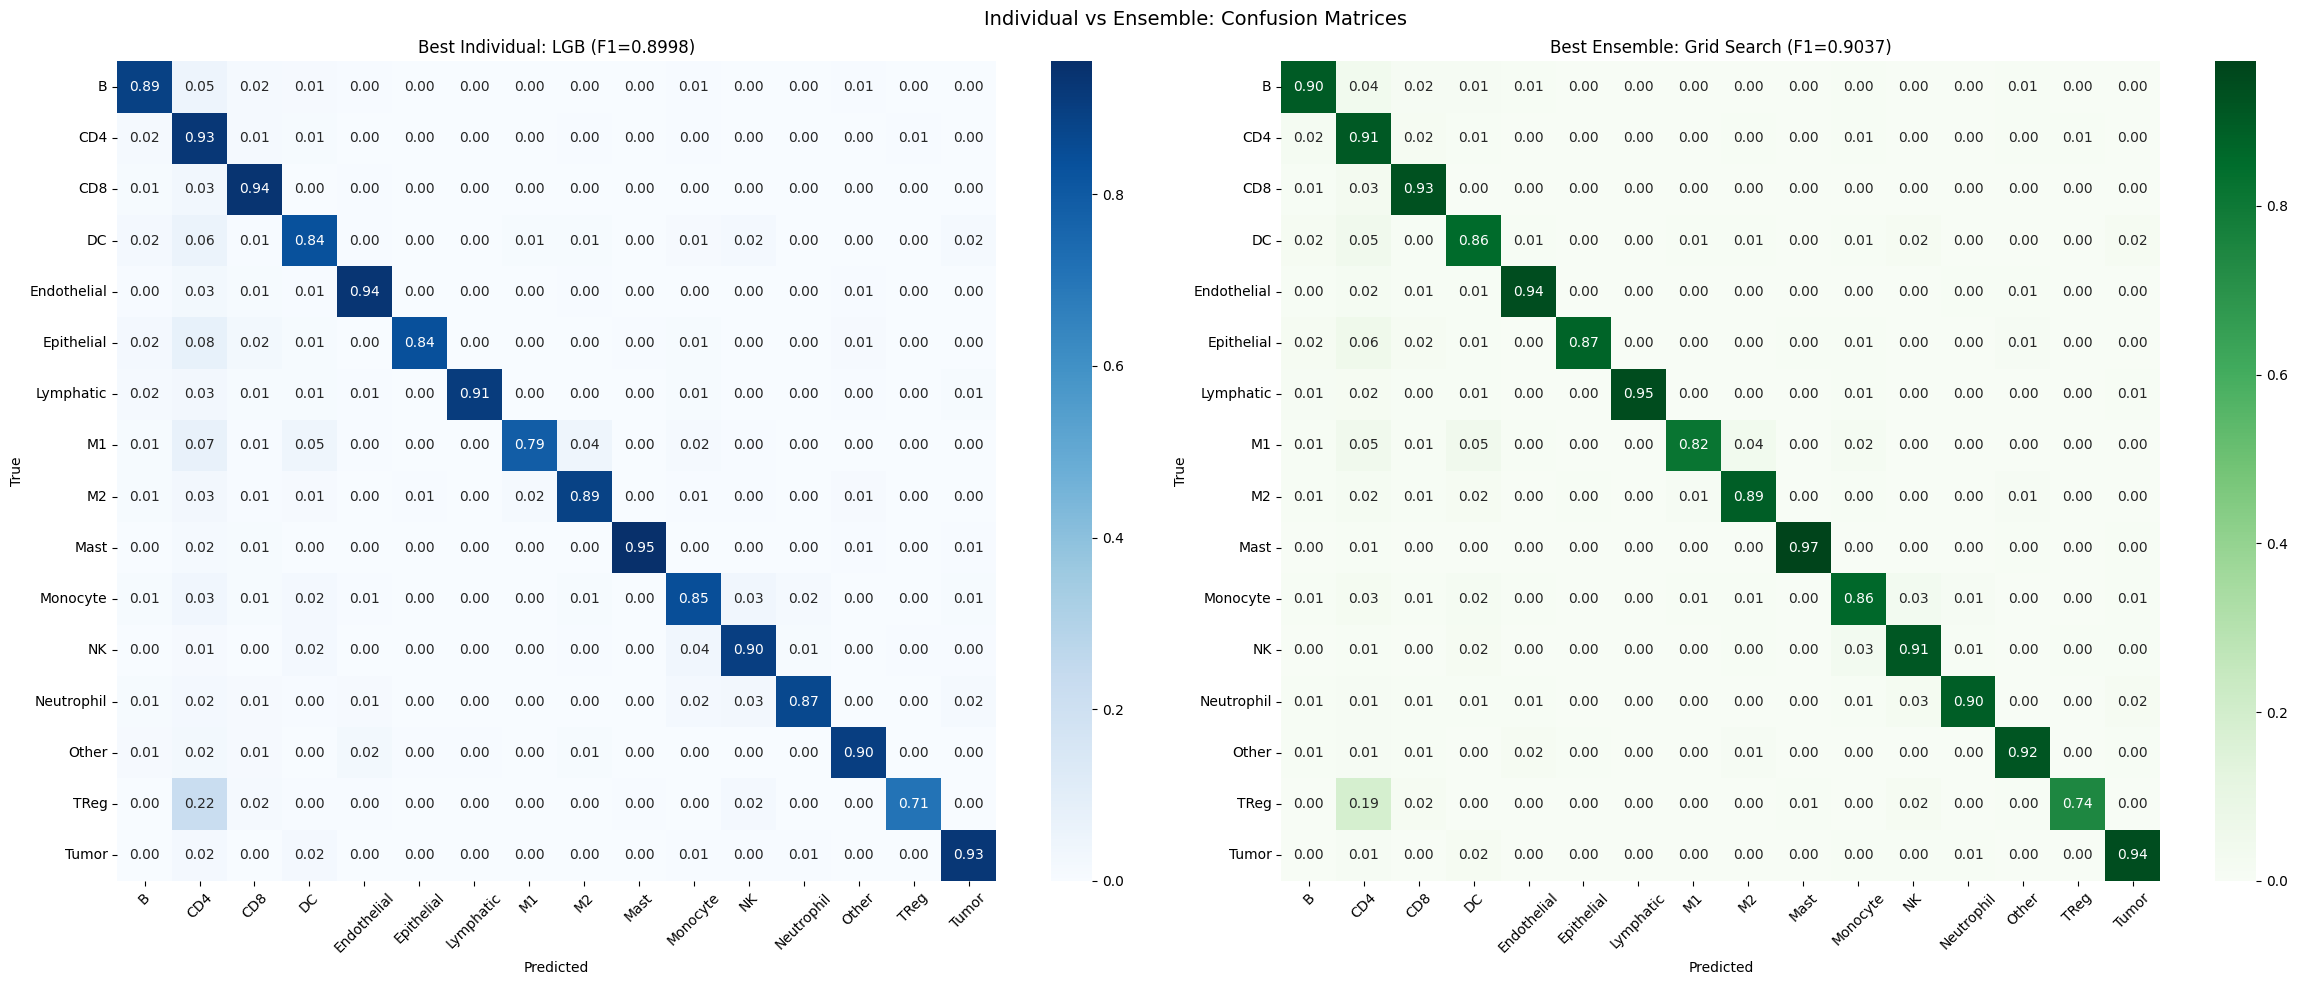

In [11]:
# Confusion matrix for best ensemble
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Best individual
best_indiv = max([('MLP', mlp_preds, mlp_f1), ('LGB', lgb_preds, lgb_f1),
                  ('XGB', xgb_preds, xgb_f1)], key=lambda x: x[2])
cm1 = confusion_matrix(y_valid, best_indiv[1])
cm1_norm = cm1.astype('float') / cm1.sum(axis=1, keepdims=True)
sns.heatmap(cm1_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'Best Individual: {best_indiv[0]} (F1={best_indiv[2]:.4f})', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# Best ensemble
cm2 = confusion_matrix(y_valid, best_preds)
cm2_norm = cm2.astype('float') / cm2.sum(axis=1, keepdims=True)
sns.heatmap(cm2_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f'Best Ensemble: {best_method[0]} (F1={best_method[1]["f1"]:.4f})', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Individual vs Ensemble: Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

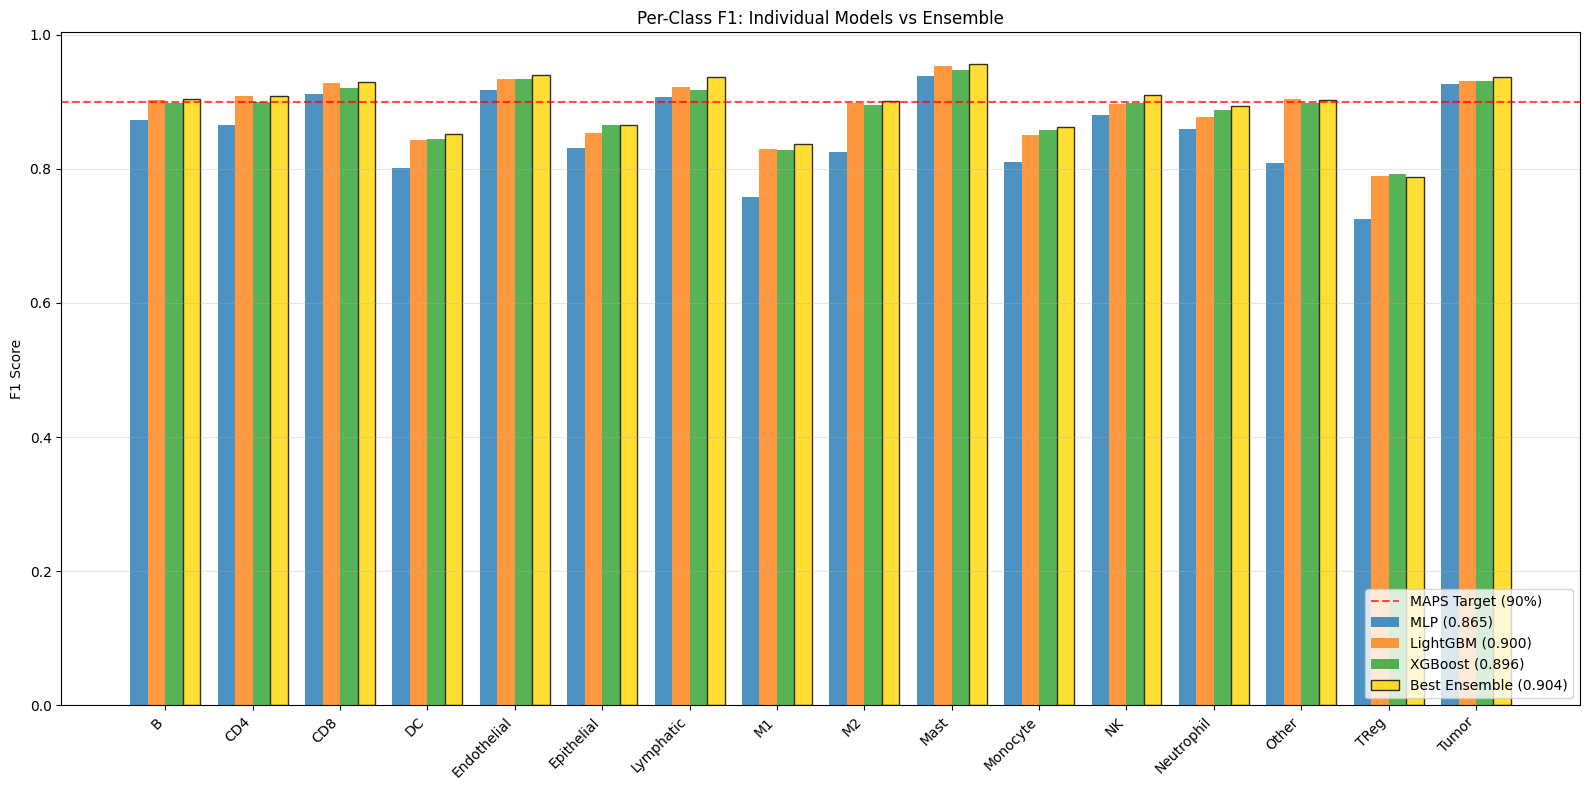

In [12]:
# Per-class F1 comparison across all methods
fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(NUM_CLASSES)
width = 0.2

mlp_per = f1_score(y_valid, mlp_preds, average=None)
lgb_per = f1_score(y_valid, lgb_preds, average=None)
xgb_per = f1_score(y_valid, xgb_preds, average=None)
ens_per = f1_score(y_valid, best_preds, average=None)

ax.bar(x - 1.5*width, mlp_per, width, label=f'MLP ({mlp_f1:.3f})', alpha=0.8)
ax.bar(x - 0.5*width, lgb_per, width, label=f'LightGBM ({lgb_f1:.3f})', alpha=0.8)
ax.bar(x + 0.5*width, xgb_per, width, label=f'XGBoost ({xgb_f1:.3f})', alpha=0.8)
ax.bar(x + 1.5*width, ens_per, width, label=f'Best Ensemble ({best_method[1]["f1"]:.3f})', alpha=0.8, color='gold', edgecolor='black')

ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='MAPS Target (90%)')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: Individual Models vs Ensemble')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

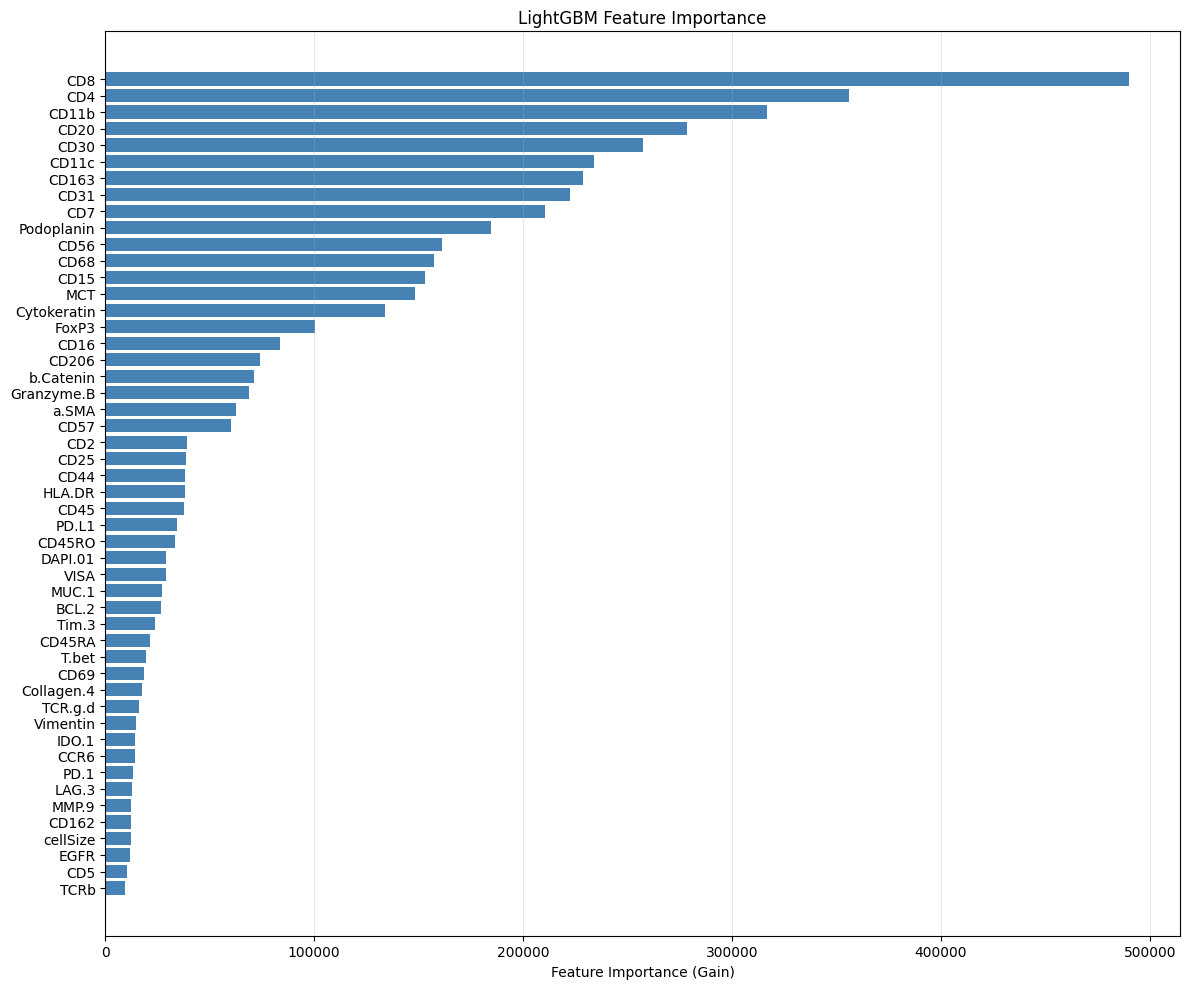


Top-10 most important features:
  CD8                 : 489920
  CD4                 : 355887
  CD11b               : 316813
  CD20                : 278562
  CD30                : 257465
  CD11c               : 233794
  CD163               : 228491
  CD31                : 222459
  CD7                 : 210720
  Podoplanin          : 184822


In [13]:
# Feature importance from LightGBM
fig, ax = plt.subplots(figsize=(12, 10))
importance = lgb_model.feature_importance(importance_type='gain')
feat_imp = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importance})
feat_imp = feat_imp.sort_values('importance', ascending=True)

ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('LightGBM Feature Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop-10 most important features:")
for _, row in feat_imp.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:20s}: {row['importance']:.0f}")

In [14]:
# Model agreement analysis
agree_all = (mlp_preds == lgb_preds) & (lgb_preds == xgb_preds)
agree_mlp_lgb = mlp_preds == lgb_preds
agree_mlp_xgb = mlp_preds == xgb_preds
agree_lgb_xgb = lgb_preds == xgb_preds

print("\nModel Agreement Analysis:")
print(f"  All 3 agree:      {agree_all.mean():.1%} ({agree_all.sum():,} / {len(y_valid):,})")
print(f"  MLP + LightGBM:   {agree_mlp_lgb.mean():.1%}")
print(f"  MLP + XGBoost:    {agree_mlp_xgb.mean():.1%}")
print(f"  LightGBM + XGB:   {agree_lgb_xgb.mean():.1%}")

# When all agree, what's the accuracy?
if agree_all.any():
    acc_agree = accuracy_score(y_valid[agree_all], mlp_preds[agree_all])
    acc_disagree = accuracy_score(y_valid[~agree_all], best_preds[~agree_all]) if (~agree_all).any() else 0
    print(f"\n  Accuracy when all agree:       {acc_agree:.4f}")
    print(f"  Accuracy when they disagree:    {acc_disagree:.4f}")
    print(f"  → Ensemble mostly helps on the {(~agree_all).sum():,} disagreement cases")


Model Agreement Analysis:
  All 3 agree:      86.5% (24,797 / 28,670)
  MLP + LightGBM:   88.3%
  MLP + XGBoost:    89.0%
  LightGBM + XGB:   95.1%

  Accuracy when all agree:       0.9453
  Accuracy when they disagree:    0.6388
  → Ensemble mostly helps on the 3,873 disagreement cases


In [15]:
# ====================================================================
# FINAL SUMMARY
# ====================================================================
print("\n" + "=" * 70)
print("EXPERIMENT 12: MLP + LightGBM + XGBoost ENSEMBLE - SUMMARY")
print("=" * 70)

print("\n  Individual models:")
print(f"    MLP (MAPS):     W-F1 = {mlp_f1:.4f}")
print(f"    LightGBM:       W-F1 = {lgb_f1:.4f}")
print(f"    XGBoost:        W-F1 = {xgb_f1:.4f}")

print("\n  Ensemble methods:")
print(f"    Simple Average:  W-F1 = {avg_f1:.4f}")
print(f"    Weighted Avg:    W-F1 = {weighted_f1:.4f}")
print(f"    Best-2:          W-F1 = {best2_f1:.4f} ({best2_name})")
print(f"    Majority Vote:   W-F1 = {vote_f1:.4f}")
print(f"    Grid Search:     W-F1 = {grid_f1:.4f} (w={best_weights})")

print(f"\n  BEST OVERALL: {best_method[0]} → W-F1 = {best_method[1]['f1']:.4f}")
print(f"  vs MAPS target (0.90): {(best_method[1]['f1'] - 0.90)*100:+.1f}pp")
print(f"  vs our MLP alone:      {(best_method[1]['f1'] - mlp_f1)*100:+.1f}pp")
print("=" * 70)


EXPERIMENT 12: MLP + LightGBM + XGBoost ENSEMBLE - SUMMARY

  Individual models:
    MLP (MAPS):     W-F1 = 0.8645
    LightGBM:       W-F1 = 0.8998
    XGBoost:        W-F1 = 0.8963

  Ensemble methods:
    Simple Average:  W-F1 = 0.9018
    Weighted Avg:    W-F1 = 0.9023
    Best-2:          W-F1 = 0.8998 (LightGBM+XGBoost)
    Majority Vote:   W-F1 = 0.9008
    Grid Search:     W-F1 = 0.9037 (w=(np.float64(0.30000000000000004), np.float64(0.5), np.float64(0.19999999999999996)))

  BEST OVERALL: Grid Search → W-F1 = 0.9037
  vs MAPS target (0.90): +0.4pp
  vs our MLP alone:      +3.9pp
